# A Production-Ready Phishing Email Detection Pipeline
**Anastasios Kontogiorgis**

This work develops a binary text classifier for phishing email detection, deployed as a containerized API. While building a classifier of this kind is relatively straightforward, the engineering challenge lies in evaluating its true real-world reliability and establishing what its reported performance actually measures. This notebook systematically identifies data leakage, evaluates out-of-distribution performance, and builds a robust production monitoring strategy. To maintain transparency, every operational claim is paired with a direct empirical measurement.

The dataset is the
[Kaggle Phishing Email corpus](https://www.kaggle.com/datasets/subhajournal/phishingemails),
containing 18,650 emails labelled either Safe Email or Phishing Email.

Sections 1 and 2 focus on data integrity and leakage prevention. An audit of the raw corpus establishes a leakage-free evaluation protocol, quantifying the exact performance cost of correcting data contamination. Sections 3 and 4 benchmark four candidate models and evaluate the selected model on held-out data, including its probability calibration. Sections 5 and 6 examine what the model has learned and where it undeprforms. Section 7 exports the deployment artefact. Section 8 measures how the model behaves on mail written outside the training corpus, providing a realistic boundary for the headline metrics. Section 9 concludes this work discussing findings and future work.

## 1 · Dataset Audit and Quality Assessment

Three properties of the corpus are established prior to model training: the proportion of missing or unusable text, the extent of exact duplication, and the presence of label conflicts where identical text appears under both classes.

In [1]:
import re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

SEED = 42

df = pd.read_csv("data/Phishing_Email.csv").drop(columns=["Unnamed: 0"])
df["Email Text"] = df["Email Text"].fillna("").astype(str).str.strip()

n_blank = (df["Email Text"] == "").sum()
n_placeholder = (df["Email Text"].str.lower() == "empty").sum()
print(f"rows: {len(df)}")
print(f"blank/NaN texts: {n_blank}")
print(f"literal 'empty' placeholder strings: {n_placeholder}")

work = df[(df["Email Text"] != "") & (df["Email Text"].str.lower() != "empty")].copy()
work["y"] = (work["Email Type"] == "Phishing Email").astype(int)

n_dup = work.duplicated("Email Text").sum()
conflicts = work.groupby("Email Text")["y"].nunique()
n_conflict = int((conflicts > 1).sum())
print(f"\nafter cleaning: {len(work)} rows | phishing share: {work.y.mean():.1%}")
print(f"exact duplicate rows: {n_dup} ({n_dup/len(work):.1%})")
print(f"texts appearing under BOTH labels: {n_conflict}")

rows: 18650
blank/NaN texts: 19
literal 'empty' placeholder strings: 533

after cleaning: 18098 rows | phishing share: 38.5%
exact duplicate rows: 577 (3.2%)
texts appearing under BOTH labels: 0


Of the 18,650 rows, 552 carry no usable text. Nineteen are blank and 533 hold the literal placeholder string `"empty"`, which a model would memorise as a class signal if it corellates heavily with a specific label; consequently, both categories are dropped. Among the remaining rows 3.2%, duplicate another row exactly. A random split may distribute these verbatim copies across both the training and testing sets. This can affect evaluation by promoting memorisation over generalisation when it encounters the exact same data point during testing, artificially inflating validation metrics which reflect how well the model remembers specific training examples rather unseen data. Given that no text appears under both labels (i.e. the same text labeled as `Safe` and `Phishing`), the process of deduplication did not discard any information.


## 2 · Evaluation Protocol and the Cost of Duplicate Leakage

Duplicate leakage inflates test scores by an amount that depends on the dataset. Identical features and an identical model are therefore evaluated under two protocols. The naive protocol retains duplicates and applies a random stratified split, which is the approach commonly taken with this dataset. The clean protocol deduplicates before splitting.

**Table 1:** Accuracy and F1 under the naive and clean protocols, using identical features and model.

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

def fit_eval(tr_txt, tr_y, te_txt, te_y, vectorizer=None):
    vec = vectorizer or TfidfVectorizer(stop_words="english", ngram_range=(1, 2),
                                        min_df=2, max_features=50000,
                                        sublinear_tf=True)
    Xtr, Xte = vec.fit_transform(tr_txt), vec.transform(te_txt)
    clf = LogisticRegression(max_iter=2000)
    clf.fit(Xtr, tr_y)
    pred = clf.predict(Xte)
    return dict(acc=accuracy_score(te_y, pred), f1=f1_score(te_y, pred)), vec, clf, (Xtr, Xte)

# naive protocol (duplicates left in)
tr_n, te_n = train_test_split(work, test_size=0.2, random_state=SEED, stratify=work.y)
contamination = te_n["Email Text"].isin(set(tr_n["Email Text"])).mean()
res_naive, *_ = fit_eval(tr_n["Email Text"], tr_n.y, te_n["Email Text"], te_n.y)

# clean protocol (dedupe, then split) — the protocol used for everything below
clean = work.drop_duplicates("Email Text").reset_index(drop=True)
train, test = train_test_split(clean, test_size=0.2, random_state=SEED, stratify=clean.y)
res_clean, vec, logreg, (Xtr, Xte) = fit_eval(train["Email Text"], train.y,
                                              test["Email Text"], test.y)

print(f"naive protocol: {contamination:.1%} of test rows have an exact copy in train")
pd.DataFrame([
    {"protocol": "naive (duplicates in)", **res_naive},
    {"protocol": "clean (dedupe first)",  **res_clean},
]).round(4)

naive protocol: 5.1% of test rows have an exact copy in train


,protocol,acc,f1
0,naive (duplicates in),0.9837,0.9788
1,clean (dedupe first),0.9797,0.9725


Under the naive protocol, approximately one in twenty test emails is a verbatim copy of a training sample, see Table 1. Enforcing the clean protocol removes this overlap entirely, which causes the overall classification accuracy to drop by approximately half a percentage point. This marginal decrease indicates that the classifier relies fundamentally on robust structural patterns rather than memorised strings. The remaining sections use the clean split of 14,016 training and 3,505 held-out test emails.


## 3 · Candidate Model Benchmark

Four classical models are compared on identical TF-IDF representations, using unigrams and bigrams over a 50,000-term vocabulary. Model selection is guided by three-fold cross-validated F1-scores computed strictly on the training set, preserving the held-out test data for independent validation (Section 4).

**Table 2:** Three-fold cross-validated F1 for four candidate models, computed on the training set.

In [3]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Linear SVM":          LinearSVC(random_state=SEED),
    "Multinomial NB":      MultinomialNB(),
    "Random Forest":       RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                                  random_state=SEED),
}
rows = []
for name, m in models.items():
    scores = cross_val_score(m, Xtr, train.y, cv=3, scoring="f1")
    rows.append({"model": name, "cv_f1_mean": scores.mean(), "cv_f1_sd": scores.std()})
bench = pd.DataFrame(rows).sort_values("cv_f1_mean", ascending=False)
bench.round(4)

,model,cv_f1_mean,cv_f1_sd
1,Linear SVM,0.9803,0.0013
0,Logistic Regression,0.9719,0.0013
3,Random Forest,0.9615,0.0011
2,Multinomial NB,0.9468,0.0042


As expected for high-dimensional, sparse text representations, the linear models outperform the tree ensemble (Table 2). The support vector machine (LinearSVC) achieves the highest performance, leading Logistic Regression by a statistically significant margin of 0.0084 F1; a delta exceeding the cross-validation standard deviations ($\sigma = 0.0013$) of both models. While both models scale well in high dimensions, LinearSVC's squared hinge loss assigns a zero penalty to all correctly classified instances outside the margin. Conversely, Logistic Regression's log-loss continuously penalises all data points, making it more sensitive to uninformative words.

LogisticRegression is selected for deployment. The downstream service relies on calibrated probabilities to dictate the operating threshold, power the browser interface, and feed the `/stats` telemetry monitor-capabilities, natively absent in `LinearSVC`-which only returns raw decision-function margins. LogisticRegression coefficients are directly interpretable, a strict dependency for the feature ablation analysis in Section 5. While wrapping `LinearSVC` in `CalibratedClassifierCV` would recover probabilities from the stronger model, this option is deferred; as Section 8 demonstrates, the binding constraint on model efficacy is corpus provenance rather than marginal gains in in-corpus F1 score.

Two properties of the evaluation pipeline should be noted. First, cross-validation operates on features fitted across the entire training set, meaning each fold observes vocabulary statistics partially from its held-out portion. This minor data leakage is uniform across all architectures, leaving the relative model rankings unaffected, though the absolute metrics remain mildly optimistic. The explicit evaluation on a separate, held-out corpus in Section 4 provides the unbiased baseline. Second, `LinearSVC` is seeded because its dual coordinate descent is stochastic, while `LogisticRegression` under the lbfgs solver is deterministic and requires no seed.

## 4 · Held-Out Evaluation

The selected `LinearSVC` was evaluated on a held-out set of 3,505 emails. Performance metrics at the default 0.5 decision threshold are reported in Table 3.

**Table 3:** Held-out performance of the selected Logistic Regression model ($N = 3{,}505$).

In [4]:
from sklearn.metrics import (precision_score, recall_score, roc_auc_score,
                             ConfusionMatrixDisplay, RocCurveDisplay)

proba = logreg.predict_proba(Xte)[:, 1]
pred = (proba >= 0.5).astype(int)

metrics = pd.DataFrame([{
    "accuracy":  accuracy_score(test.y, pred),
    "precision (phishing)": precision_score(test.y, pred),
    "recall (phishing)":    recall_score(test.y, pred),
    "f1 (phishing)":        f1_score(test.y, pred),
    "roc_auc":   roc_auc_score(test.y, proba),
}]).T.rename(columns={0: "held-out test"})
metrics.round(4)

,held-out test
accuracy,0.9797
precision (phishing),0.9851
recall (phishing),0.9603
f1 (phishing),0.9725
roc_auc,0.9973


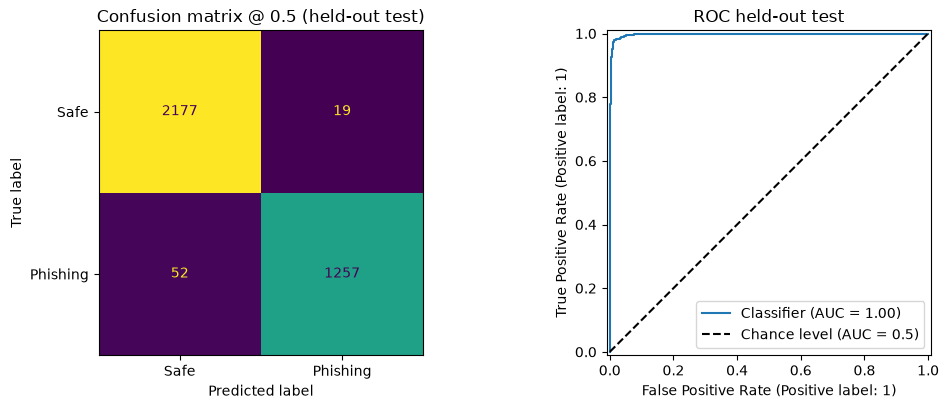

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ConfusionMatrixDisplay.from_predictions(
    test.y, pred, display_labels=["Safe", "Phishing"],
    colorbar=False, ax=axes[0]
)
axes[0].set_title("Confusion matrix @ 0.5 (held-out test)")

RocCurveDisplay.from_predictions(
    test.y, proba, ax=axes[1], plot_chance_level=True
)
axes[1].set_title("ROC held-out test")

plt.tight_layout(); plt.show()

**Figure 1:** Confusion matrix at the 0.5 threshold and ROC curve, both on the held-out test set.

The two classification error types are not symmetric in a deployed mail filter. A false positive eroneously quarantines a legitimate message, while a false negative allows a phishing message to a recipient; who may still independently recognise the threat. Precision is therefore prioritised over recall. The high precision score (0.9851) demonstrates that at the default threshold, false positives remain minimal. Addtionaly, an area under the curve (ROC AUC) of 0.9973 indicates near-ideal separation between classes, showing that the continuous decision scores reliably isolate phishing vectors regardless of the selected cutoff (0.5). 

The default 0.5 decision threshold offers a balanced, operational, compromise on this corpus (Figure 1). The exported model artefact returns a continuous probability instead of a hard class label. This design allows the operating threshold to be calibrated dynamically per deployment and revised as traffic characteristics shift over time.

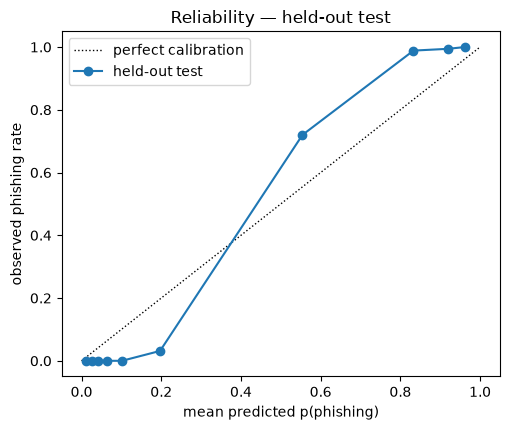

Brier score (held-out): 0.0289


In [6]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# reliability curve
observed_rate, mean_predicted = calibration_curve(test.y, proba, n_bins=10,
                                                  strategy="quantile")

fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.plot([0, 1], [0, 1], linestyle=":", color="black", linewidth=1,
        label="perfect calibration")
ax.plot(mean_predicted, observed_rate, marker="o", label="held-out test")
ax.set_xlabel("mean predicted p(phishing)")
ax.set_ylabel("observed phishing rate")
ax.set_title("Reliability — held-out test")
ax.legend()
plt.tight_layout(); plt.show()

print(f"Brier score (held-out): {brier_score_loss(test.y, proba):.4f}")

**Figure 2:** Reliability curve on the held-out test set, comparing predicted probabilities against observed frequencies.

While the ROC curve assesses only the rank-ordering of predictions (i.e. the model's ability to rank positive instances above negative ones) it does not verify whether predicted scores reflect true risk probabilities. In contrast, the reliability curve evaluates calibration by comparing how closely predicted probabilities match against observed class frequencies. 

The model exhibits strong calibration overall, yielding a low Brier score ($0.0289$). As shown in Figure 2, predicted probabilities track empirical frequencies closely at the extremes ($P \to 0$ and $P \to 1$), where the vast majority of test inferences reside. Calibration here is important as the downstream service relies on raw probability values rather than hard labels. As a result, an operating threshold maps predictably to its nominal risk level for in-distribution traffic. Section 8 evaluates how these probability estimates hold up under out-of-domain shift.

## 5 · Coefficient Inspection and the Source-Artefact Ablation

A high benchmark score warrants close scrutiny. Inspecting the fitted coefficients of the Logistic Regression model reveals which terms drive classification and provides insights on how the underlying corpus was assembled.

**Table 4:** Top 15 strongest feature weights for phishing-leaning and safe-leaning predictions.

In [7]:
names = np.array(vec.get_feature_names_out())
coef = logreg.coef_[0]
probe = pd.DataFrame({
    "top PHISHING-leaning": names[np.argsort(-coef)[:15]],
    "top SAFE-leaning":     names[np.argsort(coef)[:15]],
})
probe

,top PHISHING-leaning,top SAFE-leaning
0,click,enron
1,free,thanks
2,remove,language
3,money,2002
4,2005,wrote
5,email,university
6,2004,attached
7,site,linguistics
8,life,2001
9,online,edu


The strongest phishing coefficients align with domain expectations: click, free, remove, money, and offer (Table 4). Conversely, the top safe-leaning terms feature enron, vince, louise, linguistics, edu, and specific years (2000–2002). However, these markers do not represent intrinsic indicators of email legitimacy, but rather signatures of data provenance. The legitimate class is drawn overwhelmingly from the Enron corpus and an academic linguistics mailing list, both collected several years before the phishing samples. This sugges that the classifier is partly determining whether a message is Enron-era corporate or academic correspondence using the collection years as a temporal shortcut.

To measure how much performance relies on this shortcut, a source-masking ablation was performed. Source-identifying tokens covering corpus names, Enron-specific terminology, proper nouns, and standalone year tokens, were masked before rerunning the identical evaluation pipeline.

**Table 5:** Held-out performance with the full vocabulary versus source-identifying tokens masked.

In [8]:
ARTIFACT_RE = re.compile(r"\b(enron|hou|ect|vince|kaminski|louise|linguistics?|linguists)\b")
YEAR_RE = re.compile(r"\b(19|20)\d{2}\b")

def mask_artifacts(text):
    text = text.lower()
    text = YEAR_RE.sub(" ", text)
    return ARTIFACT_RE.sub(" ", text)

masked_vec = TfidfVectorizer(preprocessor=mask_artifacts, stop_words="english",
                             ngram_range=(1, 2), min_df=2, max_features=50000,
                             sublinear_tf=True)
res_masked, mvec, mclf, (mXtr, mXte) = fit_eval(train["Email Text"], train.y,
                                                test["Email Text"], test.y,
                                                vectorizer=masked_vec)
mproba = mclf.predict_proba(mXte)[:, 1]
res_masked["roc_auc"] = roc_auc_score(test.y, mproba)
res_clean_full = dict(res_clean, roc_auc=roc_auc_score(test.y, proba))

pd.DataFrame([
    {"features": "full vocabulary", **res_clean_full},
    {"features": "source artefacts masked", **res_masked},
]).round(4)

,features,acc,f1,roc_auc
0,full vocabulary,0.9797,0.9725,0.9973
1,source artefacts masked,0.9769,0.9686,0.9967


Masking the source-identifying vocabulary results in a small performance loss ($0.9725 \to 0.9686$ F1, Table 5), indicating that in-corpus discriminative signal is not carried by a small subset of named tokens. However, this does not establish robustness beyond the corpus—a material distinction. While the masking rule removes explicit proper nouns and dates, it leaves the broader office vocabulary characteristic of the Enron corpus, of which the legitimate class largely consists. Section 8 further demonstrates that this vocabulary carries most of the remaining discriminative weight. Overall, these findings indicate that the model has successfully learned genuine phishing indicators alongside a corpus-specific concept of legitimate mail.

## 6 · Error Analysis

In [9]:
test_view = test.copy()
test_view["proba"] = proba
fp = test_view[(test_view.y == 0) & (test_view.proba >= 0.5)].nlargest(3, "proba")
fn = test_view[(test_view.y == 1) & (test_view.proba < 0.5)].nsmallest(3, "proba")

def show(rows, title):
    print(f"=== {title} ===")
    for _, r in rows.iterrows():
        print(f"[p_phish={r.proba:.2f}] {r['Email Text'][:180]!r}")
    print()

show(fp, "False positives — safe emails the model flags (most confident)")
show(fn, "False negatives — phishing the model misses (most confident)")

=== False positives — safe emails the model flags (most confident) ===
[p_phish=0.93] 'You are receiving this email because you signed up to \nreceive one of our free reports. If you would prefer \nnot to receive messages of this type, please \nunsubscribe by following '
[p_phish=0.92] "digitize your memories with compaq scanners tired of searching for your photos or important files ? quit looking . we have a solution . we \x0f ' re offering a compaq tested and appro"
[p_phish=0.88] 'You are receiving this email because you signed up to \nreceive one of our free reports. If you would prefer \nnot to receive messages of this type, please \nunsubscribe by following '

=== False negatives — phishing the model misses (most confident) ===
[p_phish=0.14] 'call for papers : the international joint conferences on computer , information and systems sciences and engineering cisse 05 if you received this email in error , please forward i'
[p_phish=0.15] 'morozko « zero » : : : « » , , , ! ! ! - !

Legitimate messages erroneously assigned high phishing probabilities ($P > 0.88$) overwhelmingly consist of opt-in marketing materials, promotional newsletters, and automated distribution lists. This can be attributed to vocabulary oberlap of terms, meaning that terms like free, unsubscribe, offer, and click carry strong positive coefficients and when combined together push the decision boundry.

Phishing messages missed with low predicted probabilities ($P < 0.20$) exhibit domain (academic) spoofing, text obfuscation, or low-density conversational language and social engineering (referral). This can be attributed to in the first case, to the safe-leaning training set's academic bias (call for papers, conference). The second case, lacks traditional English n-grams entirely using non-English text (morozko), heavy punctuation, and timestamp tokens. This results in a sparse, near-zero TF-IDF feature vector that does not match standard English phishing unigrams or bigrams in the 50,000-term vocabulary, pushing the final prediction close to the baseline model probability rather than a high phishing score. 

## 7 · Artefact Export and Service Integration

Once the validation protocol is established on held-out data, the final production model is refitted on the complete clean dataset as standard practise to maximise vocabulary coverage and parameter precision prior to deployment.  

The entire workflow, TF-IDF feature extraction and Logistic Regression inference, are wrapped in a single scikit-learn `Pipeline` so the API receives raw text and returns a probability. Serialised to disk, the complete pipeline occupies a lightweight 2.4 MB, the exported model bobary a matadata manifest logs dataset specifications, baseline validation metrics, and label mappings.

In [10]:
import sklearn, joblib
from pathlib import Path
from datetime import date
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2,
                              max_features=50000, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=2000)),
]).fit(clean["Email Text"], clean.y)

Path("model").mkdir(exist_ok=True)
joblib.dump(pipeline, "model/phishing_pipeline.joblib")

metadata = {
    "model_version": "v2.0",
    "trained": str(date.today()),
    "sklearn_version": sklearn.__version__,
    "n_training_emails": int(len(clean)),
    "protocol": "dedupe -> stratified 80/20 split; artifact refit on all clean data",
    "held_out_metrics": {k: round(float(v), 4) for k, v in res_clean_full.items()},
    "artifact_masked_metrics": {k: round(float(v), 4) for k, v in res_masked.items()},
    "labels": {"0": "Safe Email", "1": "Phishing Email"},
}
Path("model/metadata.json").write_text(json.dumps(metadata, indent=2))
print(json.dumps(metadata, indent=2))
import os
print(f"\nartifact size: {os.path.getsize('model/phishing_pipeline.joblib')/1e6:.1f} MB")

{
  "model_version": "v2.0",
  "trained": "2026-08-28",
  "sklearn_version": "1.9.0",
  "n_training_emails": 17521,
  "protocol": "dedupe -> stratified 80/20 split; artifact refit on all clean data",
  "held_out_metrics": {
    "acc": 0.9797,
    "f1": 0.9725,
    "roc_auc": 0.9973
  },
  "artifact_masked_metrics": {
    "acc": 0.9769,
    "f1": 0.9686,
    "roc_auc": 0.9967
  },
  "labels": {
    "0": "Safe Email",
    "1": "Phishing Email"
  }
}

artifact size: 2.4 MB


## 8 · Generalisation Beyond the Training Corpus

Sections 4 and 5 establish what the classifier achieves on held-out data from the same corpus, and that the in-corpus performance does not strictly rely on source-identifying metadata. However, in-corpus evaluation cannot predict how the classifier handles mail from modern environments which is an core operational requirement for deployment.

To answer the above question and evaluate out-of-domain (OOD) generalisation of the model, a diagnostic probe set ($N = 30$) was constructed. It comprises 12 modern legitimate emails, 12 modern phishing, and 6 controls written in the vocabulary of the training corpus. The controls will confirm whether performance drops stem from domain shift or elevated sample difficulty (i.e. a decline
measured without them could be attributed to the probes being more difficult). All probes exclude URLs to isolate linguistic features.

**Table 6:** Probe set results by era and label, giving the mean predicted probability and accuracy.

In [11]:
from pathlib import Path

# the probe set: thirty short kanguage only emails written for this section, labelled and
# tagged by era
probes = pd.DataFrame([json.loads(line) for line
                       in Path("probes/modern_probes.jsonl").read_text().splitlines()
                       if line.strip()])

# score with the artefact the service loads, not the in-memory model of
# section 4, because the question concerns what the deployed system does
probes["proba"] = pipeline.predict_proba(probes.text)[:, 1]
probes["pred"] = (probes.proba >= 0.5).astype(int)
probes["correct"] = probes.pred == probes.label

summary = (probes.groupby(["era", "label"])
                 .agg(n=("proba", "size"),
                      mean_proba=("proba", "mean"),
                      accuracy=("correct", "mean"))
                 .reset_index())
summary["label"] = summary.label.map({0: "safe", 1: "phishing"})

print(f"held-out accuracy (section 4):     {res_clean_full['acc']:.3f}")
print(f"probe accuracy, modern register:   {probes[probes.era == 'modern'].correct.mean():.3f}")
print(f"probe accuracy, era controls:      {probes[probes.era == 'era-control'].correct.mean():.3f}")
summary.round(3)

held-out accuracy (section 4):     0.980
probe accuracy, modern register:   0.833
probe accuracy, era controls:      1.000


,era,label,n,mean_proba,accuracy
0,era-control,safe,3,0.048,1.000
1,era-control,phishing,3,0.894,1.000
2,modern,safe,12,0.273,0.833
3,modern,phishing,12,0.590,0.833


In [12]:
missed = probes[~probes.correct].sort_values("proba")
for _, r in missed.iterrows():
    truth = "phishing" if r.label else "safe"
    print(f"[p_phish={r.proba:.2f}] {truth:8s} | {r.category:26s} | {r.text[:80]!r}")
print(f"\n{len(missed)} of {len(probes)} probes misclassified at the 0.5 threshold")

[p_phish=0.30] phishing | shared document harvest    | 'A colleague has shared a document with you titled Q3 salary review. Sign in with'
[p_phish=0.50] phishing | password expiry harvest    | 'Your organisation password expires today. To keep your current password and avoi'
[p_phish=0.51] safe     | cloud budget alert         | 'Your monthly cost budget has reached 80 percent of the configured threshold. Cur'
[p_phish=0.63] safe     | statement available        | 'Your monthly statement is now available in the mobile application. It covers tra'

4 of 30 probes misclassified at the 0.5 threshold


While the model achieves 0.980 accuracy on the era held-out set (Section 4), accuracy drops to 0.833 on modern mail. This represents a real gap, examining prediction probabilities shown in Table 6 are more informative. On the era controls the model places a class separation margin of $\Delta = 0.846$ (mean $P = 0.048$ for safe vs. $P = 0.894$ for phishing). On modern mail the same quantity is $\Delta = 0.317$ (mean $P = 0.273$ for safe vs. $P = 0.590$ for phishing), approximately 37% of the in-corpus value (i.e. a 63% drop in class separation relative to in-domain baseline). 

Investigating closely the 4 misclassified probe modern-email predictions, the probabilities move toward the centre ($0.30 \le P \le 0.63$), two in each direction where the default $0.50$ operating threshold sits. This indicates that the model does not become confidently wrong outside its corpus, rather than becomes *uninformative* in the region of the deployed threshold. For in-corpus performance range the 0.5 threshold lies far from both modes (in-corpus predictions cluster near $0.0$ and $1.0$), while on modern mail this passes through the middle of the distribution, therefore small differences in wording may determine the classification verdict.

Investigating even more closely on the probe missclassifications: 

- $P(\text{phishing}) = 0.30$ (Phishing | False Negative): "A colleague has shared a document with you titled Q3 salary review. Sign in with...". Shows that modern SaaS document-harvesting wording is missed due to lack of traditional spam keywords that the model knows.

- $P(\text{phishing}) = 0.50$ (Phishing | Borderline False Negative): "Your organisation password expires today. To keep your current password and avoid...". Modern IAM credential-harvesting lure that lands exactly on the decision boundary.

- $P(\text{phishing}) = 0.51$ (Safe | False Positive): "Your monthly cost budget has reached 80 percent of the configured threshold. Current...". An automated cloud infrastructure alert flagged likely due to the use of transactional keywords.

- $P(\text{phishing}) = 0.63$ (Safe | False Positive): "Your monthly statement is now available in the mobile application. It covers transactions...". Modern automated banking notification misclassified potentialy due to overlap with legacy phishing terms.

### Decay Mechanisms

Three mechanisms could produce this probability compression, each implying a different remedy approach:
(i) _The vocabulary may be unfamiliar (Out-of-Vocabulary Decay)_, Modern terms (e.g., SaaS, MFA, Cloud) are absent from the 50,000-term vocabulary, causing predictions to fall back on the intercept, in which case additional data of the kind would help; (ii) _Register Shift_: Era phishing indicators appear less frequently or with altered phrasing in modern phishing lures, and (iii) _Cross-Class Feature Contamination_: modern mail may carry terms the corpus associates with the opposite class (e.g., cloud alerts, automated app notifications) heavily feature vocabulary (statement, threshold, notification) that the era training set associates primarily with phishing.

The decomposition below distinguishes them. Every prediction is a sum of per-term contributions plus
an intercept, so the score decomposes exactly, and the reconstruction check
confirms the identity holds to floating-point precision.

To isolate these mechanisms, a feature decomposition is performed bellow. As the underlying model's prediction is purely additive, the sum of individual word weights plus a baseline intercept, each final score can be broken down into exact per-term contributions. A reconstruction check confirms that this mathematical breakdown holds true to floating-point precision.

**Table 7:** Decomposition of the predicted log-odds into vocabulary coverage, supporting evidence and opposing evidence, by era and label.

In [13]:
tfidf, logistic = pipeline.named_steps["tfidf"], pipeline.named_steps["clf"]

# each term contributes tfidf_weight * coefficient to the log-odds. splitting
# those contributions by sign gives the evidence pushing each way.
contributions = tfidf.transform(probes.text).multiply(logistic.coef_[0])

probes["evidence_phishing"] = np.asarray(contributions.maximum(0).sum(axis=1)).ravel()
probes["evidence_safe"] = -np.asarray(contributions.minimum(0).sum(axis=1)).ravel()
probes["net_evidence"] = (np.asarray(contributions.sum(axis=1)).ravel()
                          + logistic.intercept_[0])

# vocabulary coverage separates two different failures: words the model has
# never seen, and familiar words that point the wrong way
analyzer = tfidf.build_analyzer()

def vocabulary_coverage(text):
    terms = analyzer(text)
    known = sum(term in tfidf.vocabulary_ for term in terms)
    return known / max(len(terms), 1)

probes["coverage"] = probes.text.map(vocabulary_coverage)

mechanism = (probes
             .groupby(["era", "label"])
             .agg(coverage=("coverage", "mean"),
                  evidence_phishing=("evidence_phishing", "mean"),
                  evidence_safe=("evidence_safe", "mean"),
                  net_evidence=("net_evidence", "mean")))

# the decomposition is an identity, not an approximation; confirm it
reconstructed = 1 / (1 + np.exp(-probes.net_evidence))
print(f"max |reconstructed - predict_proba|: {np.abs(reconstructed - probes.proba).max():.1e}")
mechanism.round(3)

max |reconstructed - predict_proba|: 1.1e-16


coverage  evidence_phishing  evidence_safe  net_evidence
era         label                                                          
era-control 0         0.622              0.058          3.480        -3.506
            1         0.625              2.505          0.275         2.147
modern      0         0.537              0.520          1.600        -1.165
            1         0.533              1.252          0.787         0.381

Vocabulary coverage falls from approximately 0.62 to 0.535, see Table 7, so the
model continues to recognise more than half the terms in modern mail and
unfamiliar words do not drive the compression. Evidence supporting the true class
approximately halves in both directions, from 3.480 to 1.600 for legitimate mail
and from 2.505 to 1.252 for phishing. Evidence supporting the incorrect class
rises in both modern groups, from 0.058 to 0.520 and from 0.275 to 0.787
respectively.

Expressed as a ratio of supporting to opposing evidence, legitimate mail falls
from roughly 60:1 to 3:1 and phishing from approximately 9:1 to 1.6:1. The corpus
conception of legitimate mail is therefore both the most strongly anchored
component of what the model learned and the most specific to its source,
restating the Section 5 finding from the opposite direction. Log-odds contract
from −3.506 to −1.165 and from +2.147 to +0.381, converging on the intercept of
−0.08, and a prediction near the intercept carries almost no information.

This is a stronger statement than the coefficient table in Section 5 supports.
Those terms were proper nouns, which a masking rule removes. The terms driving the
compression here are ordinary office vocabulary carrying an association that is
correct within the corpus and misleading outside it, and no preprocessing rule
would identify them without a second corpus for comparison.

**Table 8:** Calibration on the probe set by era, separating bias from resolution.

In [14]:
# calibration separates into two questions. bias asks whether the average
# prediction matches the base rate; resolution asks whether predictions spread
# apart enough to tell the classes apart. a model can be unbiased and still
# useless, by predicting the base rate for everything.
rows = []
for era, group in probes.groupby("era"):
    rows.append({"era": era,
                 "n": len(group),
                 "base_rate": group.label.mean(),
                 "mean_predicted": group.proba.mean(),
                 "prediction_sd": group.proba.std(),
                 "brier": brier_score_loss(group.label, group.proba)})

calibration_view = pd.DataFrame(rows)

print(f"Brier score (held-out, section 4): {brier_score_loss(test.y, proba):.4f}")
calibration_view.round(3)

Brier score (held-out, section 4): 0.0289


,era,n,base_rate,mean_predicted,prediction_sd,brier
0,era-control,6,0.5,0.471,0.465,0.008
1,modern,24,0.5,0.432,0.219,0.142


Held-out Brier is 0.0289, so the probabilities carry their stated meaning within
the corpus. On modern mail the average prediction is 0.432 against a base rate of
0.5, sufficiently close to rule out systematic bias, see Table 8. What
deteriorates is resolution. The prediction standard deviation falls from 0.465 to
0.219 and the Brier score rises from 0.008 to 0.142, indicating that the model
does not develop a preference for one class outside its corpus but ceases to
distinguish between them.

Thirty hand-written emails support no confidence interval, the probes were written
by someone already aware of the model's weaknesses, and fifteen examples per class
render the Brier figures indicative. What the probe set does establish is that the
behaviour is reproducible, that it is mechanically explained, and that it is
concentrated in the region where the operating threshold sits. Establishing its
magnitude would require an external labelled corpus, preceded by a near-duplicate
audit against this training set, since the provenance of the phishing class is
undocumented and any overlap would inflate the result.

The 0.5 threshold is a property of this corpus and should be selected per
deployment. The `/stats` endpoint and the structured request logs exist for this
reason, and the drift they monitor is measured here. The headline metrics in
Section 4 describe performance on mail resembling the training corpus, which is
the claim they support.

## 9 · Conclusions and Further Work

`app/main.py` loads the two exported files and serves them through a `/predict`
endpoint returning the label, the phishing probability and the model version, a
browser interface for manual inspection, `/health` for orchestration, and `/stats`
together with structured request logs as first-line monitoring. Section 8 measures
why that monitoring is necessary. Traffic that does not resemble the training
corpus produces predictions clustered around the threshold, making the running
prediction distribution the earliest available indication that the operating point
requires revision. Containerisation and deployment instructions are documented in
the repository README.

Two measurements would extend this work. External validation, scoring the artefact
unchanged against a labelled corpus from a different source, would convert the
Section 8 finding into a figure with a sample size behind it, provided a
near-duplicate audit against the training set is performed first. A threshold
study is the second. Given that the probabilities compress outside the corpus, the
operating point is a deployment decision, and the asymmetry between quarantining
legitimate mail and admitting a phishing message is what should determine it.
